In [1]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Setup and File Loading

import pandas as pd

FILE_PATH = '/content/drive/MyDrive/AI351ProjectTest/Consolidated Emotion Dataset.xlsx'
SELECTED_COLUMNS = ["text", "label", "label_desc"]

# Read the Excel file into a DataFrame, selecting only the required columns
try:
    df = pd.read_excel(
        FILE_PATH,
        usecols=SELECTED_COLUMNS,
        sheet_name="Consolidated Emotion Dataset"
    )

    print(f"DataFrame loaded successfully with {len(df)} rows.")
    print(f"\nFirst 5 rows:")
    print(df.head())

except FileNotFoundError:
    print(f"ERROR: File not found at the specified path: {FILE_PATH}")
except ValueError:
    print(f"ERROR: Check the column names. They might not exist in the file: {SELECTED_COLUMNS}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

DataFrame loaded successfully with 37832 rows.

First 5 rows:
                                                text  label label_desc
0                            i didnt feel humiliated      0    sadness
1  i can go from feeling so hopeless to so damned...      0    sadness
2   im grabbing a minute to post i feel greedy wrong      3      anger
3  i am ever feeling nostalgic about the fireplac...      2       love
4                               i am feeling grouchy      3      anger


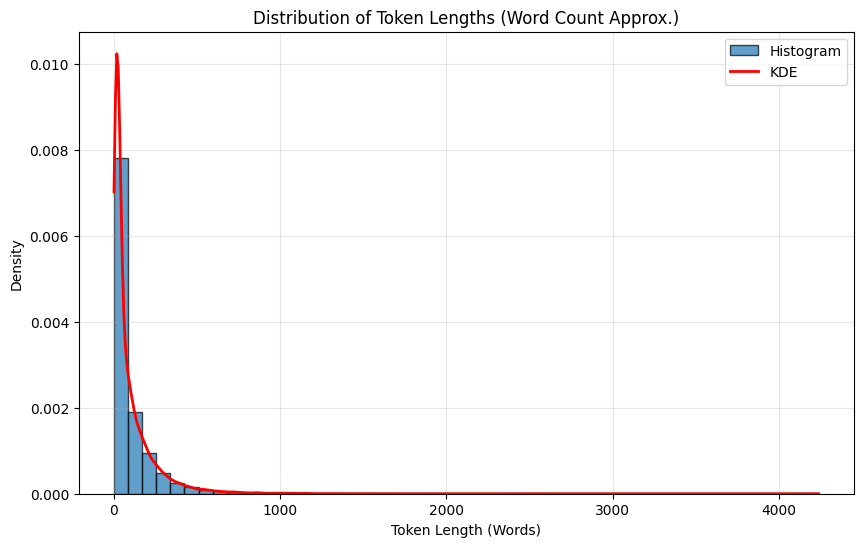

Total samples: 37832
Min: 1
Mean: 98.95744343412984
Median: 39.0
75th percentile: 125.0
95th percentile: 364.0
Max: 4239


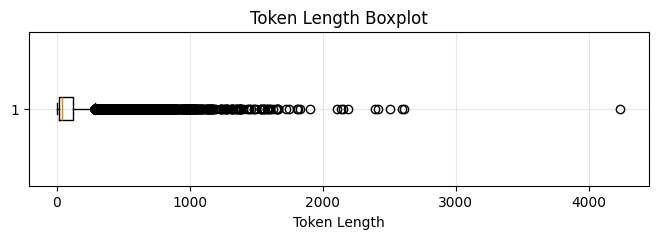

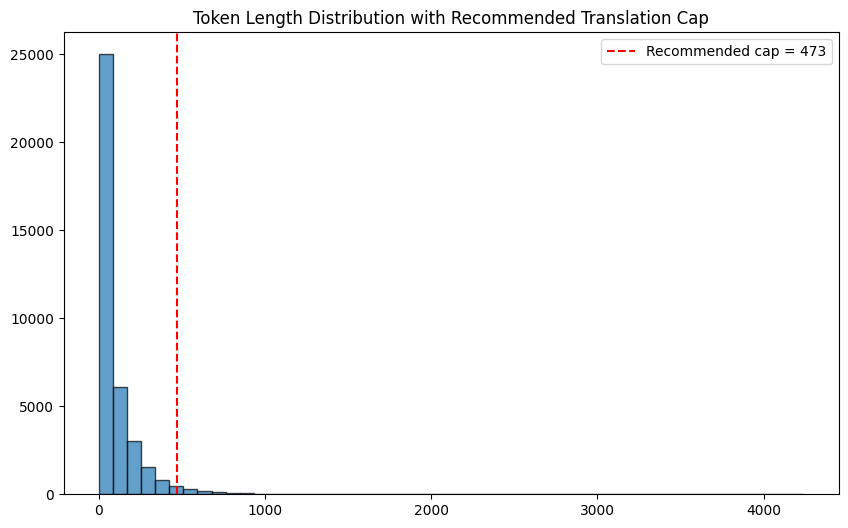

In [6]:
df["text"] = df["text"].fillna("").astype(str)
token_lengths = [len(text.split()) for text in df["text"]]
df["token_length"] = token_lengths

import matplotlib.pyplot as plt
import numpy as np

lengths = df["token_length"].values

plt.figure(figsize=(10, 6))

# Histogram
plt.hist(lengths, bins=50, alpha=0.7, edgecolor='black', density=True, label="Histogram")

# KDE approximation using numpy
from scipy.stats import gaussian_kde
kde = gaussian_kde(lengths)
x_vals = np.linspace(min(lengths), max(lengths), 500)
plt.plot(x_vals, kde(x_vals), color='red', linewidth=2, label="KDE")

plt.title("Distribution of Token Lengths (Word Count Approx.)")
plt.xlabel("Token Length (Words)")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

print("Total samples:", len(lengths))
print("Min:", np.min(lengths))
print("Mean:", np.mean(lengths))
print("Median:", np.median(lengths))
print("75th percentile:", np.percentile(lengths, 75))
print("95th percentile:", np.percentile(lengths, 95))
print("Max:", np.max(lengths))

plt.figure(figsize=(8, 2))
plt.boxplot(lengths, vert=False)
plt.title("Token Length Boxplot")
plt.xlabel("Token Length")
plt.grid(alpha=0.3)
plt.show()

recommended_cap = int(np.percentile(lengths, 95) * 1.3)
plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=50, alpha=0.7, edgecolor='black')
plt.axvline(recommended_cap, color='red', linestyle='--', label=f"Recommended cap = {recommended_cap}")
plt.legend()
plt.title("Token Length Distribution with Recommended Translation Cap")
plt.show()


## 📊 Initial Class Distribution in Full Dataset


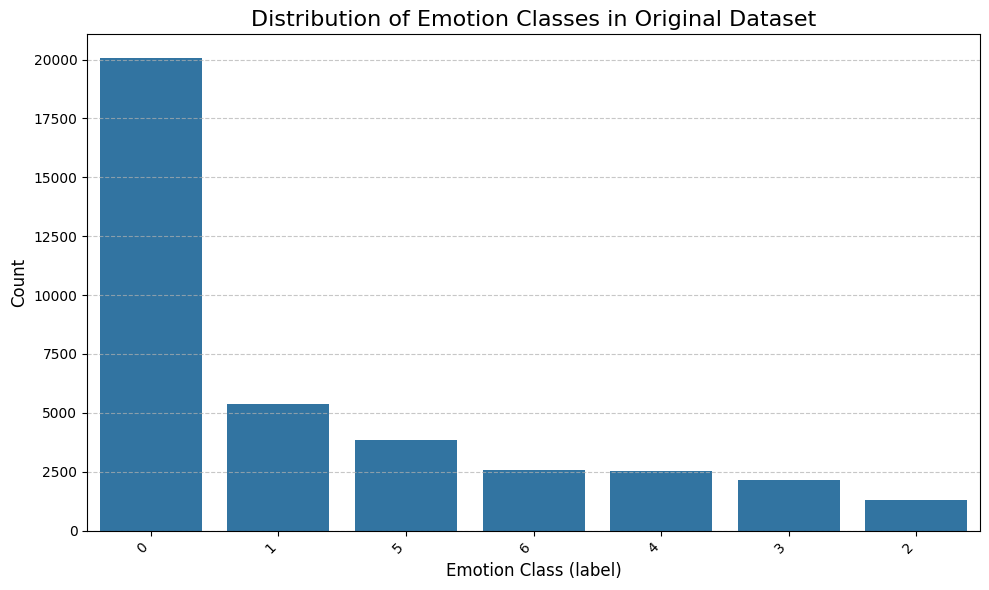

--------------------------------------------------


In [ ]:
# Distribution Analysis, Subsampling, and Reporting

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported if this is a new cell

# Show a data distribution of the classes (barchart)
print("## 📊 Initial Class Distribution in Full Dataset")

# Check for balanced/unbalanced classes before sampling
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)
plt.title('Distribution of Emotion Classes in Original Dataset', fontsize=16)
plt.xlabel('Emotion Class (label)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("-" * 50)

In [ ]:
"""

# Splitting the Dataframe into Subsamples for Saving

import numpy as np

num_parts = 10
df_parts = np.array_split(df, num_parts)

import os

FILE_PATH = '/content/drive/MyDrive/AI351ProjectTest/'

# Ensure the destination directory exists
os.makedirs(FILE_PATH, exist_ok=True)
os.makedirs("metadata", exist_ok=True)   # local backup metadata folder

for i, part in enumerate(df_parts):
    index = i + 1
    filename = f"subsample{index:02}.csv"   # subsample01.csv → subsample10.csv

    # Save locally in metadata/
    local_path = f"metadata/{filename}"
    part.to_csv(local_path, index=False)

    # Save directly to Google Drive folder
    drive_path = os.path.join(FILE_PATH, filename)
    part.to_csv(drive_path, index=False)

    print(f"Saved: {local_path}")
    print(f"Saved to Drive: {drive_path}\n")

"""


'\n\n# Splitting the Dataframe into Subsamples for Saving\n\nimport numpy as np\n\nnum_parts = 10\ndf_parts = np.array_split(df, num_parts)\n\nimport os\n\nFILE_PATH = \'/content/drive/MyDrive/AI351ProjectTest/\'\n\n# Ensure the destination directory exists\nos.makedirs(FILE_PATH, exist_ok=True)\nos.makedirs("metadata", exist_ok=True)   # local backup metadata folder\n\nfor i, part in enumerate(df_parts):\n    index = i + 1\n    filename = f"subsample{index:02}.csv"   # subsample01.csv → subsample10.csv\n\n    # Save locally in metadata/\n    local_path = f"metadata/{filename}"\n    part.to_csv(local_path, index=False)\n\n    # Save directly to Google Drive folder\n    drive_path = os.path.join(FILE_PATH, filename)\n    part.to_csv(drive_path, index=False)\n\n    print(f"Saved: {local_path}")\n    print(f"Saved to Drive: {drive_path}\n")\n\n'

In [ ]:
# Loading the Sub-Sample
import os
import pandas as pd

FILE_PATH = '/content/drive/MyDrive/AI351ProjectTest/01-MachineTranslation/'

sub_samplename = 'subsample10.csv'

FILE_PATH2 = os.path.join(FILE_PATH, sub_samplename)
SELECTED_COLUMNS2 = ["text", "label", "label_desc"]

# Read the File into a DataFrame, selecting only the required columns
try:
    df_sub = pd.read_csv(
        FILE_PATH2,
        usecols=SELECTED_COLUMNS2,
        encoding="latin1"
    )

    print(f"DataFrame loaded successfully with {len(df_sub)} rows.")
    print(f"\nFirst 5 rows:")
    display(df_sub)

except FileNotFoundError:
    print(f"ERROR: File not found at the specified path: {FILE_PATH2}")
except ValueError:
    print(f"ERROR: Check the column names. They might not exist in the file: {SELECTED_COLUMNS2}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


DataFrame loaded successfully with 3783 rows.

First 5 rows:


,text,label,label_desc
0,mental health using social anxiety and depress...,0,sadness
1,sleepless night become more frequent a i slip ...,0,sadness
2,man utd star paul pogba open up on depression ...,0,sadness
3,man utd star paul pogba open up on depression ...,0,sadness
4,look like the first stage of depression for mo...,0,sadness
...,...,...,...
3778,Nobody takes me seriously IÃ¢â¬â¢ve (24M) de...,5,anxiety
3779,"selfishness ""I don't feel very good, it's lik...",5,anxiety
3780,Is there any way to sleep better? I can't slee...,5,anxiety
3781,"Public speaking tips? Hi, all. I have to give ...",5,anxiety


In [ ]:
# Installing Dependencies

!nvidia-smi
!pip install transformers accelerate sentencepiece --quiet

Sun Dec  7 09:22:45 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             43W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
# Load the SLM (SEA-LION)

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "aisingapore/Gemma-SEA-LION-v3-9B-IT"  # SLM of choice

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    dtype=torch.float16
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

...

model-00003-of-00004.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/3.57G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

In [ ]:
# Define a Machine Translation Prompt
def build_prompt(text):
    return (
        "You are a translation engine. "
        "Translate the text into natural and standard Filipino. "
        "Maintain the original meaning, tone, and emotional content. "
        "Do not explain, summarize, rewrite, or add any commentary. "
        "Output only the translated sentence.\n\n"
        f"Text: {text}\n"
        "Translation:"
    )


In [ ]:
# Batched Translation Function
def translate_batch(text_list, batch_size=8):
    translations = []

    for i in range(0, len(text_list), batch_size):
        batch = text_list[i:i+batch_size]

        prompts = [build_prompt(t) for t in batch]
        inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True).to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=120,
                do_sample=False,    # deterministic MT
                temperature=0.0
            )

        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)

        # Extract translations cleanly
        clean = []
        for txt in decoded:
            if "Translation:" in txt:
                txt = txt.split("Translation:")[-1].strip()
            clean.append(txt)

        translations.extend(clean)

    return translations

In [ ]:
batch_size = 8
texts = df_sub["text"].tolist()
total = len(texts)

translations = []

progress_step = 5
next_progress = progress_step

for i in range(0, total, batch_size):
    batch = texts[i : i + batch_size]

    # translate this batch
    batch_trans = translate_batch(batch, batch_size=batch_size)
    translations.extend(batch_trans)

    # Calculate progress
    percent = ((i + len(batch)) / total) * 100

    if percent >= next_progress:
        print(f"Progress: {next_progress}% ({i + len(batch)}/{total})")
        next_progress += progress_step

print("Translation complete.")

df_sub_mt = df_sub.copy()
df_sub_mt["translation"] = translations


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Progress: 5% (192/3783)
Progress: 10% (384/3783)
Progress: 15% (568/3783)
Progress: 20% (760/3783)
Progress: 25% (952/3783)
Progress: 30% (1136/3783)
Progress: 35% (1328/3783)
Progress: 40% (1520/3783)
Progress: 45% (1704/3783)
Progress: 50% (1896/3783)
Progress: 55% (2088/3783)
Progress: 60% (2272/3783)
Progress: 65% (2464/3783)
Progress: 70% (2656/3783)
Progress: 75% (2840/3783)
Progress: 80% (3032/3783)
Progress: 85% (3216/3783)
Progress: 90% (3408/3783)
Progress: 95% (3600/3783)
Progress: 100% (3783/3783)
Translation complete.


In [ ]:
FILE_PATH3 = '/content/drive/MyDrive/AI351ProjectTest/01-MachineTranslation/'

# Build output filenames
output_local = f"{sub_samplename}_mt.csv"
output_drive = f"{FILE_PATH3}{sub_samplename}_mt.csv"

# Save locally
df_sub_mt.to_csv(output_local, index=False)
print(f"Saved local copy: {output_local}")

# Save to Google Drive
df_sub_mt.to_csv(output_drive, index=False)
print(f"Saved backup to Google Drive: {output_drive}")

df_sub_mt.head()


Saved local copy: subsample10.csv_mt.csv
Saved backup to Google Drive: /content/drive/MyDrive/AI351ProjectTest/01-MachineTranslation/subsample10.csv_mt.csv


,text,label,label_desc,translation
0,mental health using social anxiety and depress...,0,sadness,Kalusugan ng isip gamit ang sosyal na pag-aala...
1,sleepless night become more frequent a i slip ...,0,sadness,Ang mga gabi nang walang tulog ay lalong madal...
2,man utd star paul pogba open up on depression ...,0,sadness,Ibinahagi ni Manchester United star na si Paul...
3,man utd star paul pogba open up on depression ...,0,sadness,Ibinahagi ni Manchester United star na si Paul...
4,look like the first stage of depression for mo...,0,sadness,Parang unang yugto ng depresyon para sa karami...
